# Lab | Data Cleaning and Formatting

In this lab, we will be working with the customer data from an insurance company, which can be found in the CSV file located at the following link: https://raw.githubusercontent.com/data-bootcamp-v4/data/main/file1.csv


# Challenge 1: Data Cleaning and Formatting

## Exercise 1: Cleaning Column Names

To ensure consistency and ease of use, standardize the column names of the dataframe. Start by taking a first look at the dataframe and identifying any column names that need to be modified. Use appropriate naming conventions and make sure that column names are descriptive and informative.

*Hint*:
- *Column names should be in lower case*
- *White spaces in column names should be replaced by `_`*
- *`st` could be replaced for `state`*

In [74]:
import numpy as np
import pandas as pd

In [75]:
customer_data_insurance_df = pd.read_csv("Customer_data.csv")

In [76]:
customer_data_insurance_df.head()

,Customer,ST,GENDER,Education,Customer Lifetime Value,Income,Monthly Premium Auto,Number of Open Complaints,Policy Type,Vehicle Class,Total Claim Amount
0,RB50392,Washington,NaN,Master,NaN,0.0,1000.0,1/0/00,Personal Auto,Four-Door Car,2.704934
1,QZ44356,Arizona,F,Bachelor,697953.59%,0.0,94.0,1/0/00,Personal Auto,Four-Door Car,1131.464935
2,AI49188,Nevada,F,Bachelor,1288743.17%,48767.0,108.0,1/0/00,Personal Auto,Two-Door Car,566.472247
3,WW63253,California,M,Bachelor,764586.18%,0.0,106.0,1/0/00,Corporate Auto,SUV,529.881344
4,GA49547,Washington,M,High School or Below,536307.65%,36357.0,68.0,1/0/00,Personal Auto,Four-Door Car,17.269323


In [77]:
customer_data_insurance_df.isnull().sum()

Customer                     2937
ST                           2937
GENDER                       3054
Education                    2937
Customer Lifetime Value      2940
Income                       2937
Monthly Premium Auto         2937
Number of Open Complaints    2937
Policy Type                  2937
Vehicle Class                2937
Total Claim Amount           2937
dtype: int64

In [78]:
customer_data_insurance_clean_df = customer_data_insurance_df.copy()

In [79]:
customer_data_insurance_clean_df.columns

Index(['Customer', 'ST', 'GENDER', 'Education', 'Customer Lifetime Value',
       'Income', 'Monthly Premium Auto', 'Number of Open Complaints',
       'Policy Type', 'Vehicle Class', 'Total Claim Amount'],
      dtype='str')

In [80]:
customer_data_insurance_clean_df.columns = customer_data_insurance_clean_df.columns.str.lower().str.replace(' ', '_')

print(customer_data_insurance_clean_df.columns)

Index(['customer', 'st', 'gender', 'education', 'customer_lifetime_value',
       'income', 'monthly_premium_auto', 'number_of_open_complaints',
       'policy_type', 'vehicle_class', 'total_claim_amount'],
      dtype='str')


In [81]:
customer_data_insurance_clean_df = customer_data_insurance_clean_df.rename(columns={"st": "state"})

In [82]:
customer_data_insurance_clean_df.columns

Index(['customer', 'state', 'gender', 'education', 'customer_lifetime_value',
       'income', 'monthly_premium_auto', 'number_of_open_complaints',
       'policy_type', 'vehicle_class', 'total_claim_amount'],
      dtype='str')

## Exercise 2: Cleaning invalid Values

The dataset contains columns with inconsistent and incorrect values that could affect the accuracy of our analysis. Therefore, we need to clean these columns to ensure that they only contain valid data.

Note that this exercise will focus only on cleaning inconsistent values and will not involve handling null values (NaN or None).

*Hint*:
- *Gender column contains various inconsistent values such as "F", "M", "Femal", "Male", "female", which need to be standardized, for example, to "M" and "F".*
- *State abbreviations be can replaced with its full name, for example "AZ": "Arizona", "Cali": "California", "WA": "Washington"*
- *In education, "Bachelors" could be replaced by "Bachelor"*
- *In Customer Lifetime Value, delete the `%` character*
- *In vehicle class, "Sports Car", "Luxury SUV" and "Luxury Car" could be replaced by "Luxury"*

In [83]:
customer_data_insurance_clean_df["state"].unique()

<ArrowStringArray>
['Washington',    'Arizona',     'Nevada', 'California',     'Oregon',
       'Cali',         'AZ',         'WA',          nan]
Length: 9, dtype: str

In [84]:
state_conversion = {
    'Cali': 'California', 'AZ': 'Arizona', 'WA': 'Washington',
    'Washington': 'Washington', 'Arizona': 'Arizona', 'Nevada': 'Nevada', 'California': 'California', 'Oregon': 'Oregon'
}

customer_data_insurance_clean_df["state"] = customer_data_insurance_clean_df["state"].map(state_conversion).fillna(customer_data_insurance_clean_df["state"])

print(customer_data_insurance_clean_df["state"].unique())

<ArrowStringArray>
['Washington', 'Arizona', 'Nevada', 'California', 'Oregon', nan]
Length: 6, dtype: str


In [85]:
customer_data_insurance_clean_df["gender"].unique()

<ArrowStringArray>
[nan, 'F', 'M', 'Femal', 'Male', 'female']
Length: 6, dtype: str

In [86]:
gender_conversion = {
    "Male": "M", "Female": "F", "Femal": "F", "female" : "F"
}

customer_data_insurance_clean_df["gender"] = customer_data_insurance_clean_df["gender"].map(gender_conversion).fillna(customer_data_insurance_clean_df["gender"])

print(customer_data_insurance_clean_df["gender"].unique())

<ArrowStringArray>
[nan, 'F', 'M']
Length: 3, dtype: str


In [87]:
customer_data_insurance_clean_df["education"].unique()

<ArrowStringArray>
[              'Master',             'Bachelor', 'High School or Below',
              'College',            'Bachelors',               'Doctor',
                    nan]
Length: 7, dtype: str

In [88]:
customer_data_insurance_clean_df["education"] = customer_data_insurance_clean_df["education"].replace({
    "Bachelors": "Bachelor"
})

In [89]:
customer_data_insurance_clean_df["education"].unique()

<ArrowStringArray>
['Master', 'Bachelor', 'High School or Below', 'College', 'Doctor', nan]
Length: 6, dtype: str

In [90]:
customer_data_insurance_clean_df["customer_lifetime_value"].unique()

<ArrowStringArray>
[          nan,  '697953.59%', '1288743.17%',  '764586.18%',  '536307.65%',
  '825629.78%',  '538089.86%',  '721610.03%', '2412750.40%',  '738817.81%',
 ...
  '943891.56%', '1050677.17%',  '421391.86%',  '477368.64%',  '544142.01%',
  '284226.69%',  '305955.03%', '2031499.76%',  '323912.47%',  '899704.02%']
Length: 1028, dtype: str

In [91]:
customer_data_insurance_clean_df.dtypes

customer                         str
state                            str
gender                           str
education                        str
customer_lifetime_value          str
income                       float64
monthly_premium_auto         float64
number_of_open_complaints        str
policy_type                      str
vehicle_class                    str
total_claim_amount           float64
dtype: object

In [92]:
customer_data_insurance_clean_df["customer_lifetime_value"] = customer_data_insurance_clean_df["customer_lifetime_value"].str.replace('%', '')
customer_data_insurance_clean_df["customer_lifetime_value"].unique()

<ArrowStringArray>
[         nan,  '697953.59', '1288743.17',  '764586.18',  '536307.65',
  '825629.78',  '538089.86',  '721610.03', '2412750.40',  '738817.81',
 ...
  '943891.56', '1050677.17',  '421391.86',  '477368.64',  '544142.01',
  '284226.69',  '305955.03', '2031499.76',  '323912.47',  '899704.02']
Length: 1028, dtype: str

In [93]:
customer_data_insurance_clean_df["vehicle_class"].unique()

<ArrowStringArray>
['Four-Door Car',  'Two-Door Car',           'SUV',    'Luxury SUV',
    'Sports Car',    'Luxury Car',             nan]
Length: 7, dtype: str

In [94]:
customer_data_insurance_clean_df["vehicle_class"] = customer_data_insurance_clean_df["vehicle_class"].replace(
    {"Sports Car": "Luxury", "Luxury SUV": "Luxury", "Luxury Car": "Luxury"}
)
customer_data_insurance_clean_df["vehicle_class"].unique()

<ArrowStringArray>
['Four-Door Car', 'Two-Door Car', 'SUV', 'Luxury', nan]
Length: 5, dtype: str

## Exercise 3: Formatting data types

The data types of many columns in the dataset appear to be incorrect. This could impact the accuracy of our analysis. To ensure accurate analysis, we need to correct the data types of these columns. Please update the data types of the columns as appropriate.

It is important to note that this exercise does not involve handling null values (NaN or None).

*Hint*:
- *Customer lifetime value should be numeric*
- *Number of open complaints has an incorrect format. Look at the different values it takes with `unique()` and take the middle value. As an example, 1/5/00 should be 5. Number of open complaints is a string - remember you can use `split()` to deal with it and take the number you need. Finally, since it should be numeric, cast the column to be in its proper type.*

In [95]:
customer_data_insurance_clean_df.dtypes

customer                         str
state                            str
gender                           str
education                        str
customer_lifetime_value          str
income                       float64
monthly_premium_auto         float64
number_of_open_complaints        str
policy_type                      str
vehicle_class                    str
total_claim_amount           float64
dtype: object

In [96]:
customer_data_insurance_clean_df["customer_lifetime_value"] = pd.to_numeric(customer_data_insurance_clean_df["customer_lifetime_value"], errors='coerce')

In [97]:
print(customer_data_insurance_clean_df["customer_lifetime_value"].isnull().sum())

2940


In [98]:
customer_data_insurance_clean_df.dtypes

customer                         str
state                            str
gender                           str
education                        str
customer_lifetime_value      float64
income                       float64
monthly_premium_auto         float64
number_of_open_complaints        str
policy_type                      str
vehicle_class                    str
total_claim_amount           float64
dtype: object

In [99]:
print(customer_data_insurance_clean_df["number_of_open_complaints"].unique())

<ArrowStringArray>
['1/0/00', '1/2/00', '1/1/00', '1/3/00', '1/5/00', '1/4/00', nan]
Length: 7, dtype: str


In [100]:
customer_data_insurance_clean_df["number_of_open_complaints"] = customer_data_insurance_clean_df["number_of_open_complaints"].apply(
    lambda x: int(x.split('/')[1]) if pd.notnull(x) else x
)

In [101]:
print(customer_data_insurance_clean_df["number_of_open_complaints"].value_counts())

number_of_open_complaints
0.0    830
1.0    138
2.0     50
3.0     34
4.0     13
5.0      6
Name: count, dtype: int64


In [102]:
customer_data_insurance_clean_df["number_of_open_complaints"] = pd.to_numeric(customer_data_insurance_clean_df["number_of_open_complaints"], errors='coerce')

In [103]:
customer_data_insurance_clean_df.dtypes

customer                         str
state                            str
gender                           str
education                        str
customer_lifetime_value      float64
income                       float64
monthly_premium_auto         float64
number_of_open_complaints    float64
policy_type                      str
vehicle_class                    str
total_claim_amount           float64
dtype: object

In [104]:
customer_data_insurance_clean_df["number_of_open_complaints"] = customer_data_insurance_clean_df["number_of_open_complaints"].astype(pd.Int64Dtype())

In [105]:
customer_data_insurance_clean_df.dtypes

customer                         str
state                            str
gender                           str
education                        str
customer_lifetime_value      float64
income                       float64
monthly_premium_auto         float64
number_of_open_complaints      Int64
policy_type                      str
vehicle_class                    str
total_claim_amount           float64
dtype: object

## Exercise 4: Dealing with Null values

Identify any columns with null or missing values. Identify how many null values each column has. You can use the `isnull()` function in pandas to find columns with null values.

Decide on a strategy for handling the null values. There are several options, including:

- Drop the rows or columns with null values
- Fill the null values with a specific value (such as the column mean or median for numerical variables, and mode for categorical variables)
- Fill the null values with the previous or next value in the column
- Fill the null values based on a more complex algorithm or model (note: we haven't covered this yet)

Implement your chosen strategy to handle the null values. You can use the `fillna()` function in pandas to fill null values or `dropna()` function to drop null values.

Verify that your strategy has successfully handled the null values. You can use the `isnull()` function again to check if there are still null values in the dataset.

Remember to document your process and explain your reasoning for choosing a particular strategy for handling null values.

After formatting data types, as a last step, convert all the numeric variables to integers.

In [106]:
customer_data_insurance_clean_df.isnull().sum()

customer                     2937
state                        2937
gender                       3054
education                    2937
customer_lifetime_value      2940
income                       2937
monthly_premium_auto         2937
number_of_open_complaints    2937
policy_type                  2937
vehicle_class                2937
total_claim_amount           2937
dtype: int64

In [107]:
empty_rows = customer_data_insurance_clean_df.isnull().all(axis=1)
print("Number of entirely empty rows:", empty_rows.sum())

Number of entirely empty rows: 2937


In [108]:
#Dropping the rows that are entirely empty.
customer_data_insurance_clean_df = customer_data_insurance_clean_df.dropna(axis=0, how="all")

In [109]:
empty_rows = customer_data_insurance_clean_df.isnull().all(axis=1)
print("Number of entirely empty rows:", empty_rows.sum())

Number of entirely empty rows: 0


In [110]:
empty_columns = customer_data_insurance_clean_df.isnull().all(axis=0)
print("Number of entirely empty columns:", empty_columns.sum())

Number of entirely empty columns: 0


In [111]:
customer_data_insurance_clean_df.isnull().sum()

customer                       0
state                          0
gender                       117
education                      0
customer_lifetime_value        3
income                         0
monthly_premium_auto           0
number_of_open_complaints      0
policy_type                    0
vehicle_class                  0
total_claim_amount             0
dtype: int64

In [112]:
#Only gender and customer lifetime value have nulls.
null_clv_rows = customer_data_insurance_clean_df[customer_data_insurance_clean_df["customer_lifetime_value"].isna()]
print(null_clv_rows)

    customer       state gender             education  \
0    RB50392  Washington    NaN                Master   
78   SP81997  Washington      F                Master   
988  GT62080  Washington      M  High School or Below   

     customer_lifetime_value   income  monthly_premium_auto  \
0                        NaN      0.0                1000.0   
78                       NaN  41275.0                  96.0   
988                      NaN  55561.0                  63.0   

     number_of_open_complaints    policy_type  vehicle_class  \
0                            0  Personal Auto  Four-Door Car   
78                           0  Personal Auto  Four-Door Car   
988                          0  Personal Auto  Four-Door Car   

     total_claim_amount  
0              2.704934  
78            41.122303  
988          227.872071  


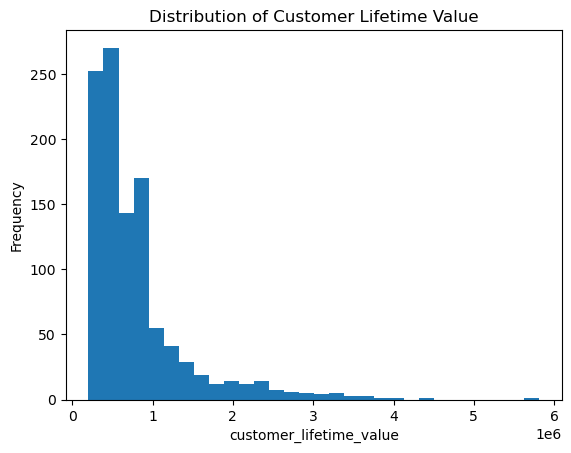

In [113]:
#Let's check the distribution of customer lifetime value
import matplotlib.pyplot as plt

customer_data_insurance_clean_df["customer_lifetime_value"].plot(kind="hist", bins=30, title="Distribution of Customer Lifetime Value")
plt.xlabel("customer_lifetime_value")
plt.ylabel("Frequency")
plt.show()

In [114]:
#Since the distribution is skewed and have some outliers, we will use the median to fill the nulls.
median_value = customer_data_insurance_clean_df["customer_lifetime_value"].median()

In [115]:
customer_data_insurance_clean_df["customer_lifetime_value"] = customer_data_insurance_clean_df["customer_lifetime_value"].fillna(median_value)

In [116]:
customer_data_insurance_clean_df.isnull().sum()

customer                       0
state                          0
gender                       117
education                      0
customer_lifetime_value        0
income                         0
monthly_premium_auto           0
number_of_open_complaints      0
policy_type                    0
vehicle_class                  0
total_claim_amount             0
dtype: int64

In [117]:
customer_data_insurance_clean_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1071 entries, 0 to 1070
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer                   1071 non-null   str    
 1   state                      1071 non-null   str    
 2   gender                     954 non-null    str    
 3   education                  1071 non-null   str    
 4   customer_lifetime_value    1071 non-null   float64
 5   income                     1071 non-null   float64
 6   monthly_premium_auto       1071 non-null   float64
 7   number_of_open_complaints  1071 non-null   Int64  
 8   policy_type                1071 non-null   str    
 9   vehicle_class              1071 non-null   str    
 10  total_claim_amount         1071 non-null   float64
dtypes: Int64(1), float64(4), str(6)
memory usage: 146.3 KB


In [118]:
#We do not have any reference for the gender nulls, so we will fill the nulls with "unknown".
customer_data_insurance_clean_df["gender"] = customer_data_insurance_clean_df["gender"].fillna("Unknown")

In [119]:
customer_data_insurance_clean_df.isnull().sum()

customer                     0
state                        0
gender                       0
education                    0
customer_lifetime_value      0
income                       0
monthly_premium_auto         0
number_of_open_complaints    0
policy_type                  0
vehicle_class                0
total_claim_amount           0
dtype: int64

## Exercise 5: Dealing with duplicates

Use the `.duplicated()` method to identify any duplicate rows in the dataframe.

Decide on a strategy for handling the duplicates. Options include:
- Dropping all duplicate rows
- Keeping only the first occurrence of each duplicated row
- Keeping only the last occurrence of each duplicated row
- Dropping duplicates based on a subset of columns
- Dropping duplicates based on a specific column

Implement your chosen strategy using the `drop_duplicates()` function.

Verify that your strategy has successfully handled the duplicates by checking for duplicates again using `.duplicated()`.

Remember to document your process and explain your reasoning for choosing a particular strategy for handling duplicates.

Save the cleaned dataset to a new CSV file.

*Hint*: *after dropping duplicates, reset the index to ensure consistency*.

In [120]:
customer_data_insurance_clean_df.duplicated().sum()

np.int64(0)

In [121]:
#The dataframe as no duplicated.

In [122]:
# Resetting the index of the DataFrame
customer_data_insurance_clean_df = customer_data_insurance_clean_df.reset_index(drop=True)

# Bonus: Challenge 2: creating functions on a separate `py` file

Put all the data cleaning and formatting steps into functions, and create a main function that performs all the cleaning and formatting.

Write these functions in separate .py file(s). By putting these steps into functions, we can make the code more modular and easier to maintain.

*Hint: autoreload module is a utility module in Python that allows you to automatically reload modules in the current session when changes are made to the source code. This can be useful in situations where you are actively developing code and want to see the effects of changes you make without having to constantly restart the Python interpreter or Jupyter Notebook kernel.*

In [123]:
customer_data_insurance2_df =customer_data_insurance_df.copy()

In [124]:
def cle_for(df, state_conversion, gender_conversion):
    # Standardizing names
    df.columns = df.columns.str.lower().str.replace(" ", "_")

    # Drop rows where all elements are NaN
    df = df.dropna(axis=0, how="all")
    
    # Map and replace categories
    df["st"] = df["st"].map(state_conversion).fillna(df["st"])
    df["gender"] = df["gender"].map(gender_conversion).ffillna(df["gender"])
    
    # Replace categories in education and vehicle_class
    df['education'] = df['education'].replace({'Bachelors': 'Bachelor'})
    df['vehicle_class'] = df['vehicle_class'].replace({
        'Sports Car': 'Luxury', 'Luxury SUV': 'Luxury', 'Luxury Car': 'Luxury'
    })
    
    # Handle 'customer_lifetime_value'
    df['customer_lifetime_value'] = df['customer_lifetime_value'].str.replace('%', '', regex=False)
    df['customer_lifetime_value'] = pd.to_numeric(
        df['customer_lifetime_value'], errors='coerce'
    )
    median_value = df['customer_lifetime_value'].median()
    df['customer_lifetime_value'] = df['customer_lifetime_value'].fillna(median_value)
    
    # Handle 'number_of_open_complaints'
    df['number_of_open_complaints'] = df['number_of_open_complaints'].apply(
        lambda x: int(x.split('/')[1]) if pd.notnull(x) else x
    ).astype(pd.Int64Dtype())  # This handles NaNs properly with Int64
        
    # Reset index
    df = df.reset_index(drop=True)
    
    return df

In [125]:
state_conversion = {
    'Cali': 'California', 'AZ': 'Arizona', 'WA': 'Washington',
    'Washington': 'Washington', 'Arizona': 'Arizona', 'Nevada': 'Nevada', 'California': 'California', 'Oregon': 'Oregon'
}

In [126]:
gender_conversion = {
    "Male": "M", "Female": "F", "Femal": "F"
}

In [127]:
%reload_ext autoreload
%autoreload 2

from function import cle_for

In [128]:
# Clean and format the DataFrame
cleaned_df = cle_for(customer_data_insurance2_df, state_conversion, gender_conversion)
cleaned_df = cleaned_df.reset_index(drop=True)

# Display the result
print(cleaned_df)

     customer          st gender             education  \
0     RB50392  Washington    NaN                Master   
1     QZ44356     Arizona      F              Bachelor   
2     AI49188      Nevada      F              Bachelor   
3     WW63253  California      M              Bachelor   
4     GA49547  Washington      M  High School or Below   
...       ...         ...    ...                   ...   
1066  TM65736      Oregon      M                Master   
1067  VJ51327  California      F  High School or Below   
1068  GS98873     Arizona      F              Bachelor   
1069  CW49887  California      F                Master   
1070  MY31220  California      F               College   

      customer_lifetime_value   income  monthly_premium_auto  \
0                  588174.235      0.0                1000.0   
1                  697953.590      0.0                  94.0   
2                 1288743.170  48767.0                 108.0   
3                  764586.180      0.0         

# Bonus: Challenge 3: Analyzing Clean and Formated Data

You have been tasked with analyzing the data to identify potential areas for improving customer retention and profitability. Your goal is to identify customers with a high policy claim amount and a low customer lifetime value.

In the Pandas Lab, we only looked at high policy claim amounts because we couldn't look into low customer lifetime values. If we had tried to work with that column, we wouldn't have been able to because customer lifetime value wasn't clean and in its proper format. So after cleaning and formatting the data, let's get some more interesting insights!

Instructions:

- Review the statistics again for total claim amount and customer lifetime value to gain an understanding of the data.
- To identify potential areas for improving customer retention and profitability, we want to focus on customers with a high policy claim amount and a low customer lifetime value. Consider customers with a high policy claim amount to be those in the top 25% of the total claim amount, and clients with a low customer lifetime value to be those in the bottom 25% of the customer lifetime value. Create a pandas DataFrame object that contains information about customers with a policy claim amount greater than the 75th percentile and a customer lifetime value in the bottom 25th percentile.
- Use DataFrame methods to calculate summary statistics about the high policy claim amount and low customer lifetime value data. To do so, select both columns of the dataframe simultaneously and pass it to the `.describe()` method. This will give you descriptive statistics, such as mean, median, standard deviation, minimum and maximum values for both columns at the same time, allowing you to compare and analyze their characteristics.

In [129]:
# Calculate the 75th percentile for total_claim_amount and 25th percentile for customer_lifetime_value
claim_75th_percentile = cleaned_df["total_claim_amount"].quantile(0.75)
clv_25th_percentile = cleaned_df["customer_lifetime_value"].quantile(0.25)

# Filter for high claim amounts and low customer lifetime value
filtered_df = cleaned_df[
    (cleaned_df["total_claim_amount"] > claim_75th_percentile) &
    (cleaned_df["customer_lifetime_value"] < clv_25th_percentile)
]

# Calculate and display summary statistics
summary_stats = filtered_df[["total_claim_amount", "customer_lifetime_value"]].describe()

print(summary_stats)

       total_claim_amount  customer_lifetime_value
count           40.000000                40.000000
mean           723.776577            341577.910000
std            149.280606             56921.472027
min            537.600000            228759.690000
25%            633.378846            304220.875000
50%            685.284189            365995.370000
75%            799.200000            387364.700000
max           1185.988301            402381.440000


In [130]:
#Analysis
#Improving Profitability:
#Since these customers have high claims but lower lifetime values, efforts could be focused on converting these engagements into higher value-over-time by upselling or developing relevant service enhancements.
#Variability Management:
#Given the variability in both claim amounts and lifetime values, customized approaches targeting customers near the max end of claims and low end of lifetime values might provide growth, or conversely, scrutinize unsustainable customer relationships.
#Retention Focus:
#Identifying potential for loyalty programs or incentives to this customer subset can drive customer retention and extend lifetime value, particularly focusing on getting lower-value customers to contribute higher ongoing profit